# Classification with Sparse Sensor Placement

This notebook builds a binary SSPOC classification problem from the same 2D transient temperature family used in the previous SparseSensing notebooks. The labels separate low-alpha nominal fields from high-alpha shifted-hotspot fields. The pySensors model runs immediately; the RAVEN cell uses the planned `<Goal subType="classification">` XML surface and will execute once the core classification implementation is available.


In [1]:
import html
import os
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import animation
import numpy as np
import pandas as pd
import pysensors as ps
from IPython.display import HTML, display
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "ravenframework").is_dir() and (path / "tests").is_dir():
            return path
    raise RuntimeError("Could not locate the repository root from the current working directory.")


repo_root = find_repo_root()
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.22})
CLASS_NAMES = {0: "low_alpha", 1: "high_alpha_shifted"}


## Data and Labels

Each sample is one 2D temperature snapshot. The spatial grid matches the other 2D tutorials; the class label is attached per time snapshot so the classification matrix has one row per `(alpha, time)` pair.


In [2]:
NX = 18
NY = 12
NT = 8
x_axis = np.linspace(0.0, 1.0, NX)
y_axis = np.linspace(0.0, 1.0, NY)
times = np.linspace(0.0, 1.0, NT)
XX, YY = np.meshgrid(x_axis, y_axis, indexing="xy")
X = XX.ravel()
Y = YY.ravel()
point_id = np.arange(X.size)


def class_label(alpha):
    return int(alpha >= 0.56)


def two_dimensional_field(alpha):
    shifted = class_label(alpha) == 1
    shift = 0.11 if shifted else 0.0
    left = np.exp(-(((X - (0.25 + 0.10 * alpha + 0.04 * shift)) / 0.16) ** 2 + ((Y - (0.35 + 0.20 * shift)) / 0.18) ** 2))
    right = np.exp(-(((X - (0.72 - 0.30 * shift)) / 0.18) ** 2 + ((Y - (0.68 - 0.08 * alpha + 0.10 * shift)) / 0.16) ** 2))
    wave = np.sin((2.0 + alpha) * np.pi * X) * np.cos(2.0 * np.pi * Y)
    return (
        np.exp(-0.85 * times[:, None]) * ((2.0 + 0.25 * alpha) * left[None, :] + (0.6 + 1.35 * alpha) * right[None, :])
        + 0.28 * np.cos(2.0 * np.pi * times[:, None]) * wave[None, :]
    )


def build_classification_matrix(alphas):
    matrices = []
    labels = []
    rows = []
    for alpha in alphas:
        label = class_label(alpha)
        field = two_dimensional_field(alpha)
        matrices.append(field)
        labels.extend([label] * len(times))
        for time in times:
            rows.append({"alpha": alpha, "time": time, "classLabel": label, "className": CLASS_NAMES[label]})
    return np.vstack(matrices), np.asarray(labels, dtype=int), pd.DataFrame(rows)


def field_image(values):
    return np.asarray(values, dtype=float).reshape(NY, NX)


def spatial_frame(ax, values, title, limits=None, cmap="coolwarm", sensors=None):
    if limits is None:
        limits = (float(np.min(values)), float(np.max(values)))
    image = ax.imshow(
        field_image(values),
        extent=[x_axis.min(), x_axis.max(), y_axis.min(), y_axis.max()],
        origin="lower",
        cmap=cmap,
        vmin=limits[0],
        vmax=limits[1],
        interpolation="bicubic",
        aspect="equal",
    )
    if sensors is not None:
        sensors = np.asarray(sensors, dtype=int)
        ax.scatter(X[sensors], Y[sensors], facecolors="none", edgecolors="black", s=88, linewidths=1.2)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    return image


def nearest_point_indices(frame):
    grid = np.column_stack([X, Y])
    indices = []
    distances = []
    for _, row in frame.iterrows():
        point = np.array([row["x"], row["y"]])
        distance = np.linalg.norm(grid - point, axis=1)
        index = int(np.argmin(distance))
        indices.append(index)
        distances.append(float(distance[index]))
    return np.asarray(indices, dtype=int), np.asarray(distances)


def style_accuracy(table):
    def highlight(row):
        if row.get("accuracy", 0.0) >= 0.95:
            return ["background-color: #d9ead3; color: #073b18" for _ in row]
        if row.get("accuracy", 0.0) >= 0.8:
            return ["background-color: #fff2cc; color: #4a3600" for _ in row]
        return ["background-color: #f4cccc; color: #5f1010" for _ in row]
    return table.style.apply(highlight, axis=1).format({"accuracy": "{:.3f}"}).hide(axis="index")


def style_sensor_comparison(table, caption, columns=None):
    if columns is None:
        columns = [
            "case", "match", "order_match", "sensor_id", "pySensors order", "RAVEN order",
            "pySensors value", "RAVEN value", "pySensors coefficient",
            "pySensors x", "RAVEN x", "pySensors y", "RAVEN y", "nearest_grid_distance",
        ]
    visible_columns = [column for column in columns if column in table.columns]

    def highlight(row):
        sensor_match = bool(row.get("match", False))
        order_match = bool(row.get("order_match", True))
        if sensor_match and order_match:
            return ["background-color: #d9ead3; color: #073b18" for _ in row]
        if sensor_match:
            return ["background-color: #fff2cc; color: #4a3600" for _ in row]
        return ["background-color: #f4cccc; color: #5f1010" for _ in row]

    fmt = {
        "match": lambda value: "yes" if bool(value) else "no",
        "order_match": lambda value: "yes" if bool(value) else "no",
        "pySensors order": "{:.0f}",
        "RAVEN order": "{:.0f}",
        "pySensors value": "{:.6f}",
        "RAVEN value": "{:.6f}",
        "pySensors coefficient": "{:.6f}",
        "pySensors x": "{:.6f}",
        "RAVEN x": "{:.6f}",
        "pySensors y": "{:.6f}",
        "RAVEN y": "{:.6f}",
        "nearest_grid_distance": "{:.2e}",
    }
    return (
        table[visible_columns]
        .style
        .apply(highlight, axis=1)
        .format({key: value for key, value in fmt.items() if key in visible_columns}, na_rep="-")
        .hide(axis="index")
        .set_caption(caption)
    )


def style_match_table(table, caption):
    def highlight(row):
        if bool(row.get("match", False)):
            return ["background-color: #d9ead3; color: #073b18" for _ in row]
        return ["background-color: #f4cccc; color: #5f1010" for _ in row]

    fmt = {
        "match": lambda value: "yes" if bool(value) else "no",
        "pySensors rmse": "{:.6e}",
        "RAVEN rec_rmse": "{:.6e}",
        "relative_l2": "{:.6e}",
        "rmse": "{:.6e}",
    }
    return (
        table
        .style
        .apply(highlight, axis=1)
        .format({key: value for key, value in fmt.items() if key in table.columns}, na_rep="-")
        .hide(axis="index")
        .set_caption(caption)
    )

train_alphas = np.array([0.12, 0.25, 0.38, 0.50, 0.64, 0.77, 0.90, 1.02])
test_alphas = np.array([0.18, 0.44, 0.70, 0.96])
train_matrix, y_train, train_meta = build_classification_matrix(train_alphas)
test_matrix, y_test, test_meta = build_classification_matrix(test_alphas)

print(f"training matrix shape: {train_matrix.shape}")
print(f"test matrix shape: {test_matrix.shape}")
train_meta.groupby(["classLabel", "className"]).size().rename("snapshots").reset_index()


training matrix shape: (64, 216)
test matrix shape: (32, 216)


,classLabel,className,snapshots
0,0,low_alpha,32
1,1,high_alpha_shifted,32


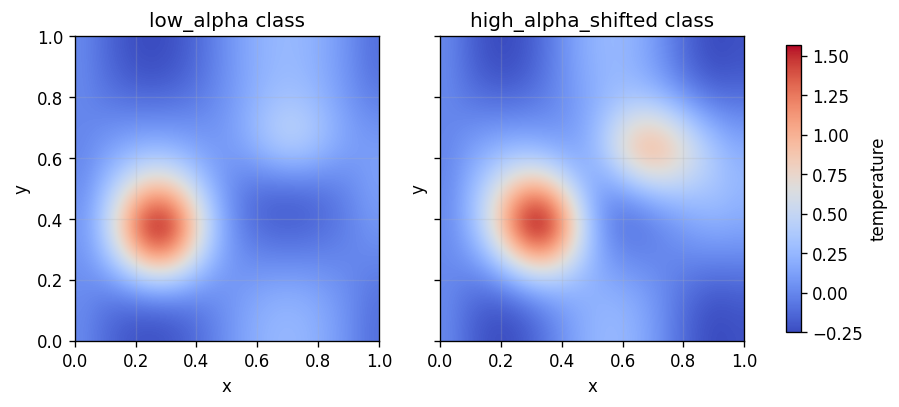

In [3]:
low_example = train_matrix[np.flatnonzero(y_train == 0)[3]]
high_example = train_matrix[np.flatnonzero(y_train == 1)[3]]
limits = (float(min(low_example.min(), high_example.min())), float(max(low_example.max(), high_example.max())))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharex=True, sharey=True)
left = spatial_frame(axes[0], low_example, "low_alpha class", limits=limits)
right = spatial_frame(axes[1], high_example, "high_alpha_shifted class", limits=limits)
fig.colorbar(left, ax=axes, shrink=0.82, label="temperature")
plt.show()


## pySensors SSPOC Baseline

SSPOC learns a sparse set of spatial measurements that preserve the class separation. The classifier below is the default linear discriminant classifier used by pySensors, with an SVD basis and a fixed sensor count.


In [4]:
n_modes = 2
n_sensors = 2
l1_penalty = 0.05
threshold = None

sspoc_model = ps.SSPOC(
    basis=ps.basis.SVD(n_basis_modes=n_modes, random_state=42),
    classifier=LinearDiscriminantAnalysis(),
    n_sensors=n_sensors,
    threshold=threshold,
    l1_penalty=l1_penalty,
)
sspoc_model.fit(train_matrix, y_train, quiet=True)
selected = sspoc_model.get_selected_sensors().astype(int)
y_pred = sspoc_model.predict(test_matrix[:, selected])
py_accuracy = accuracy_score(y_test, y_pred)
py_confusion = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=[0, 1]),
    index=["true low_alpha", "true high_alpha_shifted"],
    columns=["pred low_alpha", "pred high_alpha_shifted"],
)

sensor_coef = np.asarray(sspoc_model.sensor_coef_)
if sensor_coef.ndim > 1:
    sensor_strength = np.max(np.abs(sensor_coef), axis=1)
else:
    sensor_strength = np.abs(sensor_coef)

pysensors_sensor_table = pd.DataFrame({
    "order": np.arange(1, len(selected) + 1),
    "sensor_id": selected,
    "x": X[selected],
    "y": Y[selected],
    "coefficient": sensor_strength[selected],
})

print(f"selected sensors: {selected.tolist()}")
print(f"pySensors test accuracy: {py_accuracy:.3f}")
display(style_accuracy(pd.DataFrame([{"source": "pySensors SSPOC", "accuracy": py_accuracy, "n_sensors": len(selected)}])))
display(py_confusion)
pysensors_sensor_table


selected sensors: [137, 0]
pySensors test accuracy: 1.000


source,accuracy,n_sensors
pySensors SSPOC,1.000,2


,pred low_alpha,pred high_alpha_shifted
true low_alpha,16,0
true high_alpha_shifted,0,16


,order,sensor_id,x,y,coefficient
0,1,137,0.647059,0.636364,3.880661
1,2,0,0.000000,0.000000,0.000000


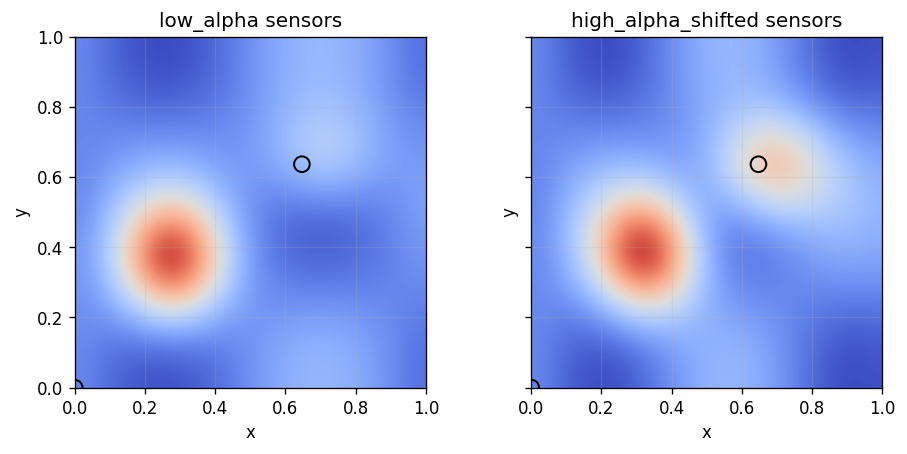

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharex=True, sharey=True)
spatial_frame(axes[0], low_example, "low_alpha sensors", limits=limits, sensors=selected)
spatial_frame(axes[1], high_example, "high_alpha_shifted sensors", limits=limits, sensors=selected)
plt.show()


## pySensors Code and RAVEN XML

The left side is the direct pySensors model. The right side is the intended RAVEN postprocessor block for Worker A's classification implementation.


In [6]:
pysensors_code = f"""
model = ps.SSPOC(
    basis=ps.basis.SVD(n_basis_modes={n_modes}, random_state=42),
    classifier=LinearDiscriminantAnalysis(),
    n_sensors={n_sensors},
    threshold={threshold!r},
    l1_penalty={l1_penalty},
)
model.fit(train_matrix, y_train, quiet=True)
selected = model.get_selected_sensors()
y_pred = model.predict(test_matrix[:, selected])
""".strip()

threshold_xml = "" if threshold is None else f"\n      <threshold>{threshold}</threshold>"
raven_xml_block = f"""
<PostProcessor name="mySPSL" subType="SparseSensing">
  <Goal subType="classification">
    <features>x, y, T</features>
    <target>T</target>
    <label>classLabel</label>
    <basis>SVD</basis>
    <nModes>{n_modes}</nModes>
    <nSensors>{n_sensors}</nSensors>
    <l1Penalty>{l1_penalty}</l1Penalty>{threshold_xml}
    <pivotParameter>time</pivotParameter>
    <reshape>snapshot</reshape>
    <seed>42</seed>
  </Goal>
</PostProcessor>
""".strip()

HTML(f"""
<table style="width:100%; border-collapse:collapse; table-layout:fixed;">
  <tr>
    <th style="width:50%; text-align:left; border:1px solid #d0d7de; padding:8px; background:#f6f8fa;">pySensors SSPOC</th>
    <th style="width:50%; text-align:left; border:1px solid #d0d7de; padding:8px; background:#f6f8fa;">RAVEN SparseSensing PostProcessor</th>
  </tr>
  <tr>
    <td style="vertical-align:top; border:1px solid #d0d7de; padding:0;">
      <pre style="white-space:pre-wrap; overflow-x:auto; margin:0; padding:12px; background:#ffffff;"><code>{html.escape(pysensors_code)}</code></pre>
    </td>
    <td style="vertical-align:top; border:1px solid #d0d7de; padding:0;">
      <pre style="white-space:pre-wrap; overflow-x:auto; margin:0; padding:12px; background:#ffffff;"><code>{html.escape(raven_xml_block)}</code></pre>
    </td>
  </tr>
</table>
""")


pySensors SSPOC,RAVEN SparseSensing PostProcessor
"model = ps.SSPOC( basis=ps.basis.SVD(n_basis_modes=2, random_state=42), classifier=LinearDiscriminantAnalysis(), n_sensors=2, threshold=None, l1_penalty=0.05, ) model.fit(train_matrix, y_train, quiet=True) selected = model.get_selected_sensors() y_pred = model.predict(test_matrix[:, selected])","<PostProcessor name=""mySPSL"" subType=""SparseSensing""> <Goal subType=""classification""> <features>x, y, T</features> <target>T</target> <label>classLabel</label> <basis>SVD</basis> <nModes>2</nModes> <nSensors>2</nSensors> <l1Penalty>0.05</l1Penalty> <pivotParameter>time</pivotParameter> <reshape>snapshot</reshape> <seed>42</seed> </Goal> </PostProcessor>"


## Build the RAVEN Case

The ExternalModel emits `T(time, pointID)` and `classLabel(time)`. The label is numeric for DataObject compatibility, with `0 = low_alpha` and `1 = high_alpha_shifted`.


In [7]:
raven_case_dir = repo_root / "tutorials" / "SparseSensing" / "_raven_runs" / "classification_sspoc"
raven_case_dir.mkdir(parents=True, exist_ok=True)
raven_alpha_values = " ".join(f"{value:.17g}" for value in train_alphas)

(raven_case_dir / "genNotebookClassification2D.py").write_text(
    textwrap.dedent(
        """\
        import numpy as np

        NX = 18
        NY = 12
        NT = 8
        X_AXIS = np.linspace(0.0, 1.0, NX)
        Y_AXIS = np.linspace(0.0, 1.0, NY)
        TIMES = np.linspace(0.0, 1.0, NT)
        XX, YY = np.meshgrid(X_AXIS, Y_AXIS, indexing='xy')
        X = XX.ravel()
        Y = YY.ravel()

        def read_alpha(Input, default=0.5):
          if isinstance(Input, dict):
            raw = Input.get('alpha', default)
          else:
            raw = getattr(Input, 'alpha', default)
          return float(np.asarray(raw).reshape(-1)[0])

        def class_label(alpha):
          return int(alpha >= 0.56)

        def two_dimensional_field(alpha):
          shifted = class_label(alpha) == 1
          shift = 0.11 if shifted else 0.0
          left = np.exp(-(((X - (0.25 + 0.10 * alpha + 0.04 * shift)) / 0.16) ** 2 + ((Y - (0.35 + 0.20 * shift)) / 0.18) ** 2))
          right = np.exp(-(((X - (0.72 - 0.30 * shift)) / 0.18) ** 2 + ((Y - (0.68 - 0.08 * alpha + 0.10 * shift)) / 0.16) ** 2))
          wave = np.sin((2.0 + alpha) * np.pi * X) * np.cos(2.0 * np.pi * Y)
          return (
              np.exp(-0.85 * TIMES[:, None]) * ((2.0 + 0.25 * alpha) * left[None, :] + (0.6 + 1.35 * alpha) * right[None, :])
              + 0.28 * np.cos(2.0 * np.pi * TIMES[:, None]) * wave[None, :]
          )

        def run(self, Input):
          alpha = read_alpha(Input)
          label = class_label(alpha)
          self.time = TIMES
          self.pointID = np.arange(X.size)
          self.x = X.copy()
          self.y = Y.copy()
          self.T = two_dimensional_field(alpha)
          self.classLabel = np.full(TIMES.shape, label, dtype=int)
          self._indexMap = {'x': ['pointID'], 'y': ['pointID'], 'T': ['time', 'pointID'], 'classLabel': ['time']}
        """
    ).lstrip()
)

raven_input = raven_case_dir / "classification_sspoc.xml"
raven_input.write_text(
    textwrap.dedent(
        f"""\
        <?xml version="1.0" ?>
        <Simulation verbosity="quiet">
          <RunInfo>
            <WorkingDir>.</WorkingDir>
            <Sequence>sample, pp, print</Sequence>
            <batchSize>1</batchSize>
          </RunInfo>
          <Models>
            <ExternalModel name="genT" subType="" ModuleToLoad="genNotebookClassification2D">
              <inputs>alpha</inputs>
              <outputs>time, pointID, x, y, T, classLabel</outputs>
            </ExternalModel>
            <PostProcessor name="mySPSL" subType="SparseSensing">
              <Goal subType="classification">
                <features>x, y, T</features>
                <target>T</target>
                <label>classLabel</label>
                <basis>SVD</basis>
                <nModes>{n_modes}</nModes>
                <nSensors>{n_sensors}</nSensors>
                <optimizer>QR</optimizer>
                <l1Penalty>{l1_penalty}</l1Penalty>
                <pivotParameter>time</pivotParameter>
                <reshape>snapshot</reshape>
                <seed>42</seed>
              </Goal>
            </PostProcessor>
          </Models>
          <Distributions>
            <Uniform name="uniAlpha">
              <lowerBound>0.0</lowerBound>
              <upperBound>1.1</upperBound>
            </Uniform>
          </Distributions>
          <Samplers>
            <Grid name="alphaGrid">
              <variable name="alpha">
                <distribution>uniAlpha</distribution>
                <grid construction="custom" type="value">{raven_alpha_values}</grid>
              </variable>
            </Grid>
          </Samplers>
          <Steps>
            <MultiRun name="sample">
              <Input class="DataObjects" type="PointSet">placeholder</Input>
              <Model class="Models" type="ExternalModel">genT</Model>
              <Sampler class="Samplers" type="Grid">alphaGrid</Sampler>
              <Output class="DataObjects" type="DataSet">dataDS</Output>
            </MultiRun>
            <PostProcess name="pp">
              <Input class="DataObjects" type="DataSet">dataDS</Input>
              <Model class="Models" type="PostProcessor">mySPSL</Model>
              <Output class="DataObjects" type="DataSet">outPP</Output>
            </PostProcess>
            <IOStep name="print">
              <Input class="DataObjects" type="DataSet">outPP</Input>
              <Output class="OutStreams" type="Print">outPP</Output>
            </IOStep>
          </Steps>
          <DataObjects>
            <PointSet name="placeholder">
              <Input>alpha</Input>
              <Output>OutputPlaceHolder</Output>
            </PointSet>
            <DataSet name="dataDS">
              <Input>alpha</Input>
              <Output>x, y, T, classLabel</Output>
              <Index var="time">T, classLabel</Index>
              <Index var="pointID">x, y, T</Index>
            </DataSet>
            <DataSet name="outPP">
              <Output>x, y, T</Output>
              <Index var="sensor">x, y, T</Index>
            </DataSet>
          </DataObjects>
          <OutStreams>
            <Print name="outPP">
              <type>csv</type>
              <source>outPP</source>
              <what>output</what>
            </Print>
          </OutStreams>
        </Simulation>
        """
    )
)
print(f"RAVEN input: {raven_input}")


RAVEN input: /Users/abdomg/projects/raven-pysensors-alignment/tutorials/SparseSensing/_raven_runs/classification_sspoc/classification_sspoc.xml


## Run RAVEN

This cell is intentionally executable before the classification branch lands. If the current RAVEN core rejects the classification XML, the notebook records that status and continues with the pySensors baseline.


In [8]:
raven_case_dir.mkdir(parents=True, exist_ok=True)
raven_output = raven_case_dir / "outPP.csv"
if raven_output.exists():
    raven_output.unlink()

import subprocess
run_env = os.environ.copy()
run_env["PATH"] = f"{repo_root}{os.pathsep}{run_env.get('PATH', '')}"
run_env["INSTALLATION_MANAGER"] = "CONDA"
run_env["RAVEN_LIBS_NAME"] = "raven_spsl_043"
run_env["PYTHON_COMMAND"] = sys.executable
run_env.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "mpl_raven"))
run_env.setdefault("IPYTHONDIR", str(Path("/tmp") / "ipython"))

print(f"$ raven_framework {raven_input.name}")
run_result = subprocess.run(
    ["raven_framework", raven_input.name],
    cwd=str(raven_case_dir),
    env=run_env,
    text=True,
    capture_output=True,
)
print(run_result.stdout)
if run_result.stderr:
    print(run_result.stderr)

combined_log = f"{run_result.stdout}\n{run_result.stderr}"
missing_classification_core = (
    "classification is not yet implemented" in combined_log
    or ("not in the input specs" in combined_log and any(token in combined_log for token in ["label", "l1Penalty", "threshold"]))
)
raven_classification_available = False
raven_output_available = False

if run_result.returncode != 0:
    if missing_classification_core:
        print("RAVEN classification support is not available in this workspace yet; continuing with the pySensors baseline.")
    else:
        raise RuntimeError(f"RAVEN failed with exit code {run_result.returncode}")
elif not raven_output.exists():
    print(f"RAVEN completed but did not write {raven_output}")
else:
    raven_classification_available = True
    raven_output_available = True
    print(f"Fresh RAVEN run completed: {raven_output}")


$ raven_framework classification_sspoc.xml
CONDA
raven_spsl_043       *   /Users/abdomg/miniconda3/envs/raven_spsl_043
Running RAVEN in "opt" mode.

Copyright 2017 Battelle Energy Alliance, LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
  

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

      .---.        .------######       #####     ###   ###  ########  ###    ###
     /     \  __  /    --###  ###    ###  ###   ###   ###  ###       #####  ###
    / /     \(  )/    --###  ###    ##

## Sensor Comparison

When RAVEN classification is available, this table compares the selected RAVEN locations against pySensors. Rows are green when the selected sensor and ordering match.


In [9]:
if raven_output_available:
    raven_sensor_table = pd.read_csv(raven_output)
    raven_indices, raven_distances = nearest_point_indices(raven_sensor_table)
    pysensors_compare = pd.DataFrame({
        "sensor_id": selected.astype(int),
        "pySensors order": np.arange(1, len(selected) + 1),
        "pySensors coefficient": sensor_strength[selected],
        "pySensors x": X[selected],
        "pySensors y": Y[selected],
    })
    raven_compare = pd.DataFrame({
        "sensor_id": raven_indices,
        "RAVEN order": raven_sensor_table["sensor"].to_numpy() if "sensor" in raven_sensor_table else np.arange(1, len(raven_indices) + 1),
        "RAVEN x": raven_sensor_table["x"].to_numpy(),
        "RAVEN y": raven_sensor_table["y"].to_numpy(),
        "nearest_grid_distance": raven_distances,
    })
    comparison_table = pysensors_compare.merge(raven_compare, on="sensor_id", how="outer").sort_values(["pySensors order", "RAVEN order"], na_position="last").reset_index(drop=True)
    comparison_table["same sensor"] = comparison_table["pySensors order"].notna() & comparison_table["RAVEN order"].notna()
    comparison_table["same location"] = np.isclose(comparison_table["pySensors x"], comparison_table["RAVEN x"]) & np.isclose(comparison_table["pySensors y"], comparison_table["RAVEN y"])
    comparison_table["match"] = comparison_table[["same sensor", "same location"]].all(axis=1)
    comparison_table["order_match"] = comparison_table["pySensors order"].eq(comparison_table["RAVEN order"])
    print(f"same selected sensor set: {comparison_table['match'].all() and len(comparison_table) == n_sensors}")
    print(f"same selected sensor order: {np.array_equal(selected, raven_indices)}")
    display(style_sensor_comparison(comparison_table, "RAVEN vs pySensors SSPOC sensors"))
else:
    raven_indices = np.array([], dtype=int)
    comparison_table = pd.DataFrame()
    print("RAVEN sensor comparison is pending Worker A's classification implementation.")


same selected sensor set: True
same selected sensor order: True


match,order_match,sensor_id,pySensors order,RAVEN order,pySensors coefficient,pySensors x,RAVEN x,pySensors y,RAVEN y,nearest_grid_distance
yes,yes,137,1,1,3.880661,0.647059,0.647059,0.636364,0.636364,0.00e+00
yes,yes,0,2,2,0.000000,0.000000,0.000000,0.000000,0.000000,0.00e+00


## Classification Accuracy and Confusion Tables

The pySensors accuracy is computed directly from SSPOC. When RAVEN selected sensors are available, the second row uses those RAVEN locations with the same LDA classifier on the held-out snapshots; if Worker A exposes RAVEN predictions directly, this cell can be tightened to compare those columns instead.


In [10]:
accuracy_rows = [{"source": "pySensors SSPOC", "accuracy": py_accuracy, "n_sensors": len(selected)}]
confusion_tables = {"pySensors SSPOC": py_confusion}

if raven_output_available and len(raven_indices) > 0:
    raven_sensor_classifier = LinearDiscriminantAnalysis()
    raven_sensor_classifier.fit(train_matrix[:, raven_indices], y_train)
    raven_pred = raven_sensor_classifier.predict(test_matrix[:, raven_indices])
    raven_accuracy = accuracy_score(y_test, raven_pred)
    accuracy_rows.append({"source": "RAVEN-selected sensors + LDA", "accuracy": raven_accuracy, "n_sensors": len(raven_indices)})
    confusion_tables["RAVEN-selected sensors + LDA"] = pd.DataFrame(
        confusion_matrix(y_test, raven_pred, labels=[0, 1]),
        index=["true low_alpha", "true high_alpha_shifted"],
        columns=["pred low_alpha", "pred high_alpha_shifted"],
    )

accuracy_table = pd.DataFrame(accuracy_rows)
display(style_accuracy(accuracy_table))
for name, table in confusion_tables.items():
    print(name)
    display(table)


source,accuracy,n_sensors
pySensors SSPOC,1.000,2
RAVEN-selected sensors + LDA,1.000,2


pySensors SSPOC


,pred low_alpha,pred high_alpha_shifted
true low_alpha,16,0
true high_alpha_shifted,0,16


RAVEN-selected sensors + LDA


,pred low_alpha,pred high_alpha_shifted
true low_alpha,16,0
true high_alpha_shifted,0,16


## Classification Diagnostics
SSPOC classification selects sensors for class separation, not full-field reconstruction. Since the class fields are transient, this diagnostic animates the low-alpha field, the high-alpha shifted-hotspot field, and their pointwise contrast over time with the selected sensors overlaid.


In [11]:

low_alpha = float(test_meta.loc[y_test == 0, "alpha"].iloc[0])
high_alpha = float(test_meta.loc[y_test == 1, "alpha"].iloc[0])
low_tensor = two_dimensional_field(low_alpha)
high_tensor = two_dimensional_field(high_alpha)
contrast_tensor = high_tensor - low_tensor

class_limits = (float(np.min([low_tensor.min(), high_tensor.min()])), float(np.max([low_tensor.max(), high_tensor.max()])))
contrast_limit = max(float(np.max(np.abs(contrast_tensor))), 1e-12)
contrast_limits = (-contrast_limit, contrast_limit)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.0), constrained_layout=True)
low_im = spatial_frame(axes[0], low_tensor[0], f"{CLASS_NAMES[0]} | alpha={low_alpha:.2f}, t={times[0]:.2f}", limits=class_limits, cmap="coolwarm", sensors=selected)
high_im = spatial_frame(axes[1], high_tensor[0], f"{CLASS_NAMES[1]} | alpha={high_alpha:.2f}, t={times[0]:.2f}", limits=class_limits, cmap="coolwarm", sensors=selected)
contrast_im = spatial_frame(axes[2], contrast_tensor[0], f"class contrast | t={times[0]:.2f}", limits=contrast_limits, cmap="coolwarm", sensors=selected)
fig.colorbar(low_im, ax=axes[0], shrink=0.82)
fig.colorbar(high_im, ax=axes[1], shrink=0.82)
fig.colorbar(contrast_im, ax=axes[2], shrink=0.82)


def update_classification_frame(frame_index):
    low_im.set_data(field_image(low_tensor[frame_index]))
    high_im.set_data(field_image(high_tensor[frame_index]))
    contrast_im.set_data(field_image(contrast_tensor[frame_index]))
    axes[0].set_title(f"{CLASS_NAMES[0]} | alpha={low_alpha:.2f}, t={times[frame_index]:.2f}")
    axes[1].set_title(f"{CLASS_NAMES[1]} | alpha={high_alpha:.2f}, t={times[frame_index]:.2f}")
    axes[2].set_title(f"class contrast | t={times[frame_index]:.2f}")
    return low_im, high_im, contrast_im

classification_animation = animation.FuncAnimation(fig, update_classification_frame, frames=len(times), interval=700, blit=False)
display(HTML(classification_animation.to_jshtml()))
plt.close(fig)


## Case Study: Time-Varying Alpha
When `alpha` changes with time, each trajectory is naturally a 3D tensor with shape `(trajectory, time, space)`. For an instantaneous regime classifier, the cleanest unfold is `reshape="snapshot"`: rows are `(trajectory, time)` snapshots and columns are spatial sensor candidates. HOSVD is more relevant when the class label belongs to a whole trajectory or when the basis should preserve coupled sample-time structure; here the label is time-dependent, so snapshot unfolding is the direct comparison.


In [12]:

alpha_threshold = 0.56


def alpha_history(alpha_mid, slope):
    return np.clip(alpha_mid + slope * (times - 0.5), 0.05, 1.05)


def time_varying_snapshot(alpha_value, time_value):
    shifted = alpha_value >= alpha_threshold
    shift = 0.11 if shifted else 0.0
    left = np.exp(-(((X - (0.25 + 0.10 * alpha_value + 0.04 * shift)) / 0.16) ** 2 + ((Y - (0.35 + 0.20 * shift)) / 0.18) ** 2))
    right = np.exp(-(((X - (0.72 - 0.30 * shift)) / 0.18) ** 2 + ((Y - (0.68 - 0.08 * alpha_value + 0.10 * shift)) / 0.16) ** 2))
    wave = np.sin((2.0 + alpha_value) * np.pi * X) * np.cos(2.0 * np.pi * Y)
    return (
        np.exp(-0.85 * time_value) * ((2.0 + 0.25 * alpha_value) * left + (0.6 + 1.35 * alpha_value) * right)
        + 0.28 * np.cos(2.0 * np.pi * time_value) * wave
    )


def time_varying_field(alpha_mid, slope):
    alpha_t = alpha_history(alpha_mid, slope)
    tensor = np.vstack([time_varying_snapshot(alpha_value, time_value) for alpha_value, time_value in zip(alpha_t, times)])
    labels = (alpha_t >= alpha_threshold).astype(int)
    return tensor, labels, alpha_t


def build_time_varying_matrix(alpha_mid_values, slope_values):
    matrices = []
    labels = []
    rows = []
    tensors = []
    for alpha_mid in alpha_mid_values:
        for slope in slope_values:
            tensor, label_t, alpha_t = time_varying_field(alpha_mid, slope)
            tensors.append(tensor)
            matrices.append(tensor)
            labels.extend(label_t.tolist())
            for time_value, alpha_value, label in zip(times, alpha_t, label_t):
                rows.append({"alpha_mid": alpha_mid, "slope": slope, "time": time_value, "alpha_t": alpha_value, "classLabel": int(label), "className": CLASS_NAMES[int(label)]})
    return np.vstack(matrices), np.asarray(labels, dtype=int), pd.DataFrame(rows), np.stack(tensors)


tv_train_alpha_mid = np.array([0.25, 0.40, 0.55, 0.70, 0.85])
tv_train_slopes = np.array([-0.55, -0.25, 0.0, 0.25, 0.55])
tv_test_alpha_mid = np.array([0.33, 0.50, 0.67, 0.82])
tv_test_slopes = np.array([-0.45, 0.15, 0.45])

train_tv_matrix, y_tv_train, train_tv_meta, train_tv_tensor = build_time_varying_matrix(tv_train_alpha_mid, tv_train_slopes)
test_tv_matrix, y_tv_test, test_tv_meta, test_tv_tensor = build_time_varying_matrix(tv_test_alpha_mid, tv_test_slopes)

shape_table = pd.DataFrame([
    {"object": "raw training tensor", "shape": str(train_tv_tensor.shape), "meaning": "trajectory x time x space"},
    {"object": "snapshot-unfolded training matrix", "shape": str(train_tv_matrix.shape), "meaning": "(trajectory*time) x space"},
    {"object": "time-dependent labels", "shape": str(y_tv_train.shape), "meaning": "one class per snapshot row"},
])
display(shape_table)
print(train_tv_meta.groupby(["classLabel", "className"]).size().rename("snapshots").reset_index())


,object,shape,meaning
0,raw training tensor,"(25, 8, 216)",trajectory x time x space
1,snapshot-unfolded training matrix,"(200, 216)",(trajectory*time) x space
2,time-dependent labels,"(200,)",one class per snapshot row


   classLabel           className  snapshots
0           0           low_alpha        104
1           1  high_alpha_shifted         96


## pySensors and RAVEN Mapping for Time-Varying Alpha
The key RAVEN entries are still `<pivotParameter>time</pivotParameter>` and `<reshape>snapshot</reshape>`. They tell SparseSensing to unfold the 3D tensor into snapshot rows and align `classLabel(time)` with those rows.


In [13]:

tv_n_modes = 4
tv_n_sensors = 4
tv_l1_penalty = 0.04

tv_model = ps.SSPOC(
    basis=ps.basis.SVD(n_basis_modes=tv_n_modes, random_state=42),
    classifier=LinearDiscriminantAnalysis(),
    n_sensors=tv_n_sensors,
    l1_penalty=tv_l1_penalty,
)
tv_model.fit(train_tv_matrix, y_tv_train, quiet=True)
tv_selected = tv_model.get_selected_sensors().astype(int)
tv_pred = tv_model.predict(test_tv_matrix[:, tv_selected])
tv_accuracy = accuracy_score(y_tv_test, tv_pred)

tv_sensor_coef = np.asarray(tv_model.sensor_coef_)
if tv_sensor_coef.ndim > 1:
    tv_sensor_strength = np.max(np.abs(tv_sensor_coef), axis=1)
else:
    tv_sensor_strength = np.abs(tv_sensor_coef)

tv_pysensors_table = pd.DataFrame({
    "order": np.arange(1, len(tv_selected) + 1),
    "sensor_id": tv_selected,
    "x": X[tv_selected],
    "y": Y[tv_selected],
    "coefficient": tv_sensor_strength[tv_selected],
})

pysensors_tv_code = f"""
# Raw tensor: train_tv_tensor.shape == {train_tv_tensor.shape}
# Snapshot unfold: rows=(trajectory,time), columns=space
train_tv_matrix = train_tv_tensor.reshape(-1, {X.size})
model = ps.SSPOC(
    basis=ps.basis.SVD(n_basis_modes={tv_n_modes}, random_state=42),
    classifier=LinearDiscriminantAnalysis(),
    n_sensors={tv_n_sensors},
    l1_penalty={tv_l1_penalty},
)
model.fit(train_tv_matrix, y_tv_train, quiet=True)
selected = model.get_selected_sensors()
""".strip()

raven_tv_xml = f"""
<PostProcessor name="mySPSL" subType="SparseSensing">
  <Goal subType="classification">
    <features>x, y, T</features>
    <target>T</target>
    <label>classLabel</label>
    <basis>SVD</basis>
    <nModes>{tv_n_modes}</nModes>
    <nSensors>{tv_n_sensors}</nSensors>
    <optimizer>QR</optimizer>
    <l1Penalty>{tv_l1_penalty}</l1Penalty>
    <pivotParameter>time</pivotParameter>
    <reshape>snapshot</reshape>
    <seed>42</seed>
  </Goal>
</PostProcessor>
""".strip()

print(f"time-varying alpha pySensors test accuracy: {tv_accuracy:.3f}")
display(tv_pysensors_table)
display(HTML(f"""
<table style="width:100%; border-collapse:collapse; table-layout:fixed;">
  <tr>
    <th style="width:50%; text-align:left; border:1px solid #d0d7de; padding:8px; background:#f6f8fa;">pySensors snapshot unfold</th>
    <th style="width:50%; text-align:left; border:1px solid #d0d7de; padding:8px; background:#f6f8fa;">RAVEN SparseSensing XML</th>
  </tr>
  <tr>
    <td style="vertical-align:top; border:1px solid #d0d7de; padding:0;"><pre style="white-space:pre-wrap; overflow-x:auto; margin:0; padding:12px; background:#ffffff;"><code>{html.escape(pysensors_tv_code)}</code></pre></td>
    <td style="vertical-align:top; border:1px solid #d0d7de; padding:0;"><pre style="white-space:pre-wrap; overflow-x:auto; margin:0; padding:12px; background:#ffffff;"><code>{html.escape(raven_tv_xml)}</code></pre></td>
  </tr>
</table>
"""))


time-varying alpha pySensors test accuracy: 1.000


,order,sensor_id,x,y,coefficient
0,1,58,0.235294,0.272727,20.647897
1,2,79,0.411765,0.363636,14.885943
2,3,119,0.647059,0.545455,0.147628
3,4,138,0.705882,0.636364,0.000000


pySensors snapshot unfold,RAVEN SparseSensing XML
"# Raw tensor: train_tv_tensor.shape == (25, 8, 216) # Snapshot unfold: rows=(trajectory,time), columns=space train_tv_matrix = train_tv_tensor.reshape(-1, 216) model = ps.SSPOC( basis=ps.basis.SVD(n_basis_modes=4, random_state=42), classifier=LinearDiscriminantAnalysis(), n_sensors=4, l1_penalty=0.04, ) model.fit(train_tv_matrix, y_tv_train, quiet=True) selected = model.get_selected_sensors()","<PostProcessor name=""mySPSL"" subType=""SparseSensing""> <Goal subType=""classification""> <features>x, y, T</features> <target>T</target> <label>classLabel</label> <basis>SVD</basis> <nModes>4</nModes> <nSensors>4</nSensors> <optimizer>QR</optimizer> <l1Penalty>0.04</l1Penalty> <pivotParameter>time</pivotParameter> <reshape>snapshot</reshape> <seed>42</seed> </Goal> </PostProcessor>"


## Run RAVEN for Time-Varying Alpha
This RAVEN case samples `alpha_mid` and `slope`. The ExternalModel computes `alpha(t)`, the transient temperature field, and the time-dependent `classLabel(t)` for each trajectory.


In [14]:

raven_tv_case_dir = repo_root / "tutorials" / "SparseSensing" / "_raven_runs" / "classification_alpha_time"
raven_tv_case_dir.mkdir(parents=True, exist_ok=True)
raven_tv_output = raven_tv_case_dir / "outPP.csv"
if raven_tv_output.exists():
    raven_tv_output.unlink()

raven_tv_alpha_values = " ".join(f"{value:.17g}" for value in tv_train_alpha_mid)
raven_tv_slope_values = " ".join(f"{value:.17g}" for value in tv_train_slopes)

(raven_tv_case_dir / "genNotebookAlphaTimeClassification2D.py").write_text(
    textwrap.dedent(
        f"""\
        import numpy as np

        NX = {NX}
        NY = {NY}
        NT = {NT}
        ALPHA_THRESHOLD = {alpha_threshold!r}
        X_AXIS = np.linspace(0.0, 1.0, NX)
        Y_AXIS = np.linspace(0.0, 1.0, NY)
        TIMES = np.linspace(0.0, 1.0, NT)
        XX, YY = np.meshgrid(X_AXIS, Y_AXIS, indexing='xy')
        X = XX.ravel()
        Y = YY.ravel()

        def read_value(Input, name, default=0.0):
          if isinstance(Input, dict):
            raw = Input.get(name, default)
          else:
            raw = getattr(Input, name, default)
          return float(np.asarray(raw).reshape(-1)[0])

        def alpha_history(alpha_mid, slope):
          return np.clip(alpha_mid + slope * (TIMES - 0.5), 0.05, 1.05)

        def snapshot(alpha_value, time_value):
          shifted = alpha_value >= ALPHA_THRESHOLD
          shift = 0.11 if shifted else 0.0
          left = np.exp(-(((X - (0.25 + 0.10 * alpha_value + 0.04 * shift)) / 0.16) ** 2 + ((Y - (0.35 + 0.20 * shift)) / 0.18) ** 2))
          right = np.exp(-(((X - (0.72 - 0.30 * shift)) / 0.18) ** 2 + ((Y - (0.68 - 0.08 * alpha_value + 0.10 * shift)) / 0.16) ** 2))
          wave = np.sin((2.0 + alpha_value) * np.pi * X) * np.cos(2.0 * np.pi * Y)
          return (
              np.exp(-0.85 * time_value) * ((2.0 + 0.25 * alpha_value) * left + (0.6 + 1.35 * alpha_value) * right)
              + 0.28 * np.cos(2.0 * np.pi * time_value) * wave
          )

        def run(self, Input):
          alpha_mid = read_value(Input, 'alpha_mid', 0.5)
          slope = read_value(Input, 'slope', 0.0)
          alpha_t = alpha_history(alpha_mid, slope)
          self.time = TIMES
          self.pointID = np.arange(X.size)
          self.x = X.copy()
          self.y = Y.copy()
          self.alpha_t = alpha_t
          self.T = np.vstack([snapshot(alpha_value, time_value) for alpha_value, time_value in zip(alpha_t, TIMES)])
          self.classLabel = (alpha_t >= ALPHA_THRESHOLD).astype(int)
          self._indexMap = {{'x': ['pointID'], 'y': ['pointID'], 'alpha_t': ['time'], 'T': ['time', 'pointID'], 'classLabel': ['time']}}
        """
    ).lstrip()
)

raven_tv_input = raven_tv_case_dir / "classification_alpha_time.xml"
raven_tv_input.write_text(
    textwrap.dedent(
        f"""\
        <?xml version="1.0" ?>
        <Simulation verbosity="quiet">
          <RunInfo>
            <WorkingDir>.</WorkingDir>
            <Sequence>sample, pp, print</Sequence>
            <batchSize>1</batchSize>
          </RunInfo>
          <Models>
            <ExternalModel name="genT" subType="" ModuleToLoad="genNotebookAlphaTimeClassification2D">
              <inputs>alpha_mid, slope</inputs>
              <outputs>time, pointID, x, y, alpha_t, T, classLabel</outputs>
            </ExternalModel>
            {raven_tv_xml}
          </Models>
          <Distributions>
            <Uniform name="uniAlphaMid"><lowerBound>0.0</lowerBound><upperBound>1.1</upperBound></Uniform>
            <Uniform name="uniSlope"><lowerBound>-0.7</lowerBound><upperBound>0.7</upperBound></Uniform>
          </Distributions>
          <Samplers>
            <Grid name="trajectoryGrid">
              <variable name="alpha_mid">
                <distribution>uniAlphaMid</distribution>
                <grid construction="custom" type="value">{raven_tv_alpha_values}</grid>
              </variable>
              <variable name="slope">
                <distribution>uniSlope</distribution>
                <grid construction="custom" type="value">{raven_tv_slope_values}</grid>
              </variable>
            </Grid>
          </Samplers>
          <Steps>
            <MultiRun name="sample">
              <Input class="DataObjects" type="PointSet">placeholder</Input>
              <Model class="Models" type="ExternalModel">genT</Model>
              <Sampler class="Samplers" type="Grid">trajectoryGrid</Sampler>
              <Output class="DataObjects" type="DataSet">dataDS</Output>
            </MultiRun>
            <PostProcess name="pp">
              <Input class="DataObjects" type="DataSet">dataDS</Input>
              <Model class="Models" type="PostProcessor">mySPSL</Model>
              <Output class="DataObjects" type="DataSet">outPP</Output>
            </PostProcess>
            <IOStep name="print"><Input class="DataObjects" type="DataSet">outPP</Input><Output class="OutStreams" type="Print">outPP</Output></IOStep>
          </Steps>
          <DataObjects>
            <PointSet name="placeholder"><Input>alpha_mid, slope</Input><Output>OutputPlaceHolder</Output></PointSet>
            <DataSet name="dataDS">
              <Input>alpha_mid, slope</Input>
              <Output>x, y, alpha_t, T, classLabel</Output>
              <Index var="time">alpha_t, T, classLabel</Index>
              <Index var="pointID">x, y, T</Index>
            </DataSet>
            <DataSet name="outPP"><Output>x, y, T</Output><Index var="sensor">x, y, T</Index></DataSet>
          </DataObjects>
          <OutStreams><Print name="outPP"><type>csv</type><source>outPP</source><what>output</what></Print></OutStreams>
        </Simulation>
        """
    ).lstrip()
)
print(f"RAVEN input: {raven_tv_input}")

print(f"$ raven_framework {raven_tv_input.name}")
tv_run_result = subprocess.run(
    ["raven_framework", raven_tv_input.name],
    cwd=str(raven_tv_case_dir),
    env=run_env,
    text=True,
    capture_output=True,
)
print(tv_run_result.stdout)
if tv_run_result.stderr:
    print(tv_run_result.stderr)
if tv_run_result.returncode != 0:
    raise RuntimeError(f"RAVEN failed with exit code {tv_run_result.returncode}")
if not raven_tv_output.exists():
    raise RuntimeError(f"RAVEN completed but did not write {raven_tv_output}")
print(f"Fresh RAVEN run completed: {raven_tv_output}")


RAVEN input: /Users/abdomg/projects/raven-pysensors-alignment/tutorials/SparseSensing/_raven_runs/classification_alpha_time/classification_alpha_time.xml
$ raven_framework classification_alpha_time.xml
CONDA
raven_spsl_043       *   /Users/abdomg/miniconda3/envs/raven_spsl_043
Running RAVEN in "opt" mode.

Copyright 2017 Battelle Energy Alliance, LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
  

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

      .---.        .------######       #

## Time-Varying Alpha Comparison
The table compares the sensors selected from the snapshot-unfolded pySensors matrix against the fresh RAVEN run on the same 3D tensor data.


In [15]:

raven_tv_sensor_table = pd.read_csv(raven_tv_output)
raven_tv_indices, raven_tv_distances = nearest_point_indices(raven_tv_sensor_table)

tv_pysensors_compare = pd.DataFrame({
    "sensor_id": tv_selected.astype(int),
    "pySensors order": np.arange(1, len(tv_selected) + 1),
    "pySensors coefficient": tv_sensor_strength[tv_selected],
    "pySensors x": X[tv_selected],
    "pySensors y": Y[tv_selected],
})
tv_raven_compare = pd.DataFrame({
    "sensor_id": raven_tv_indices,
    "RAVEN order": raven_tv_sensor_table["sensor"].to_numpy() if "sensor" in raven_tv_sensor_table else np.arange(1, len(raven_tv_indices) + 1),
    "RAVEN x": raven_tv_sensor_table["x"].to_numpy(),
    "RAVEN y": raven_tv_sensor_table["y"].to_numpy(),
    "nearest_grid_distance": raven_tv_distances,
})
tv_comparison_table = tv_pysensors_compare.merge(tv_raven_compare, on="sensor_id", how="outer").sort_values(["pySensors order", "RAVEN order"], na_position="last").reset_index(drop=True)
tv_comparison_table["same sensor"] = tv_comparison_table["pySensors order"].notna() & tv_comparison_table["RAVEN order"].notna()
tv_comparison_table["same location"] = np.isclose(tv_comparison_table["pySensors x"], tv_comparison_table["RAVEN x"]) & np.isclose(tv_comparison_table["pySensors y"], tv_comparison_table["RAVEN y"])
tv_comparison_table["match"] = tv_comparison_table[["same sensor", "same location"]].all(axis=1)
tv_comparison_table["order_match"] = tv_comparison_table["pySensors order"].eq(tv_comparison_table["RAVEN order"])
print(f"same selected sensor set: {tv_comparison_table['match'].all() and len(tv_comparison_table) == tv_n_sensors}")
print(f"same selected sensor order: {np.array_equal(tv_selected, raven_tv_indices)}")
display(style_sensor_comparison(tv_comparison_table, "RAVEN vs pySensors time-varying-alpha SSPOC sensors"))

raven_tv_classifier = LinearDiscriminantAnalysis()
raven_tv_classifier.fit(train_tv_matrix[:, raven_tv_indices], y_tv_train)
raven_tv_pred = raven_tv_classifier.predict(test_tv_matrix[:, raven_tv_indices])
raven_tv_accuracy = accuracy_score(y_tv_test, raven_tv_pred)
display(style_accuracy(pd.DataFrame([
    {"source": "pySensors time-varying alpha", "accuracy": tv_accuracy, "n_sensors": len(tv_selected)},
    {"source": "RAVEN-selected time-varying alpha", "accuracy": raven_tv_accuracy, "n_sensors": len(raven_tv_indices)},
])))


same selected sensor set: True
same selected sensor order: True


match,order_match,sensor_id,pySensors order,RAVEN order,pySensors coefficient,pySensors x,RAVEN x,pySensors y,RAVEN y,nearest_grid_distance
yes,yes,58,1,1,20.647897,0.235294,0.235294,0.272727,0.272727,2.78e-17
yes,yes,79,2,2,14.885943,0.411765,0.411765,0.363636,0.363636,5.55e-17
yes,yes,119,3,3,0.147628,0.647059,0.647059,0.545455,0.545455,0.00e+00
yes,yes,138,4,4,0.000000,0.705882,0.705882,0.636364,0.636364,0.00e+00


source,accuracy,n_sensors
pySensors time-varying alpha,1.000,4
RAVEN-selected time-varying alpha,1.000,4


## Time-Varying Alpha Animation
This animation follows one crossing trajectory. `alpha(t)` changes with time, the class label changes when it crosses the threshold, and the selected sensors remain fixed spatial locations.


In [16]:

demo_alpha_mid = 0.50
demo_slope = 0.70
demo_tensor, demo_labels, demo_alpha_t = time_varying_field(demo_alpha_mid, demo_slope)
demo_limits = (float(np.min(demo_tensor)), float(np.max(demo_tensor)))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0), constrained_layout=True)
field_im = spatial_frame(
    axes[0],
    demo_tensor[0],
    f"T(x,y,t) | alpha={demo_alpha_t[0]:.2f}, class={CLASS_NAMES[int(demo_labels[0])]}",
    limits=demo_limits,
    cmap="coolwarm",
    sensors=tv_selected,
)
fig.colorbar(field_im, ax=axes[0], shrink=0.82)
axes[1].plot(times, demo_alpha_t, color="#1f77b4", linewidth=2.0)
axes[1].axhline(alpha_threshold, color="#b23a48", linestyle="--", linewidth=1.5)
alpha_marker = axes[1].scatter([times[0]], [demo_alpha_t[0]], s=80, color="#1f77b4", zorder=3)
axes[1].set_xlim(float(times.min()), float(times.max()))
axes[1].set_ylim(0.0, 1.05)
axes[1].set_xlabel("time")
axes[1].set_ylabel("alpha(t)")
axes[1].set_title("classification threshold")


def update_alpha_time_frame(frame_index):
    field_im.set_data(field_image(demo_tensor[frame_index]))
    axes[0].set_title(f"T(x,y,t) | alpha={demo_alpha_t[frame_index]:.2f}, class={CLASS_NAMES[int(demo_labels[frame_index])]}")
    alpha_marker.set_offsets(np.array([[times[frame_index], demo_alpha_t[frame_index]]]))
    return field_im, alpha_marker

alpha_time_animation = animation.FuncAnimation(fig, update_alpha_time_frame, frames=len(times), interval=700, blit=False)
display(HTML(alpha_time_animation.to_jshtml()))
plt.close(fig)
